<a href="https://colab.research.google.com/github/Valtern/PCVK_Ganjil_2025/blob/main/week11_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import google.colab.drive
google.colab.drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt

# D1 Practicum

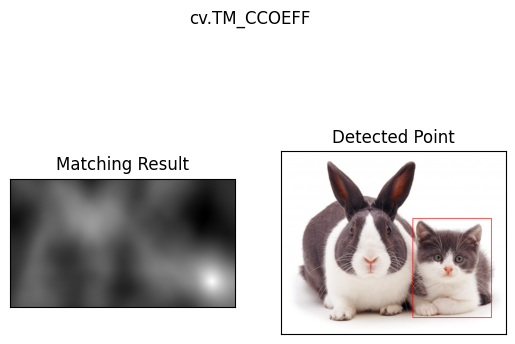

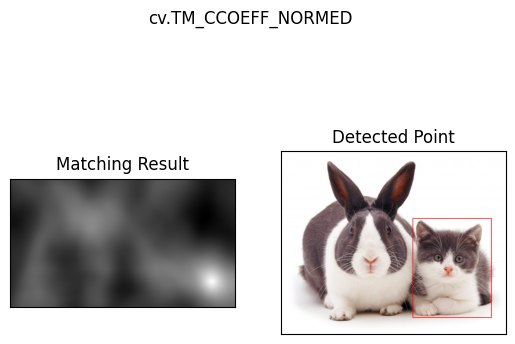

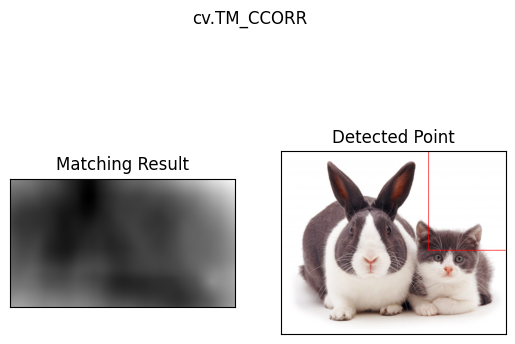

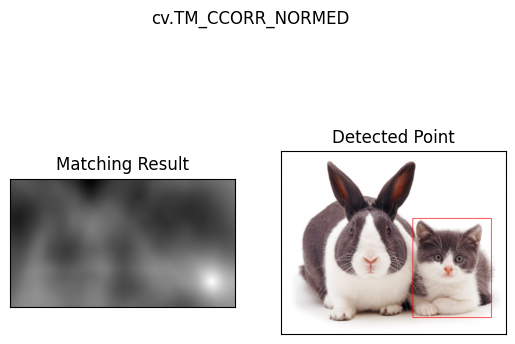

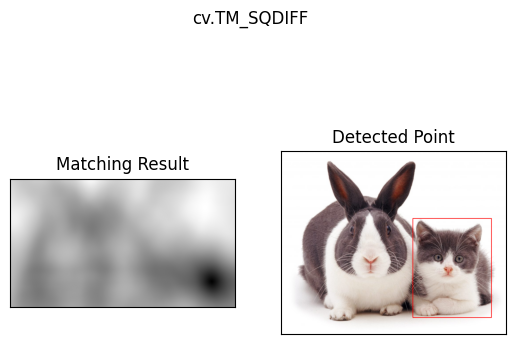

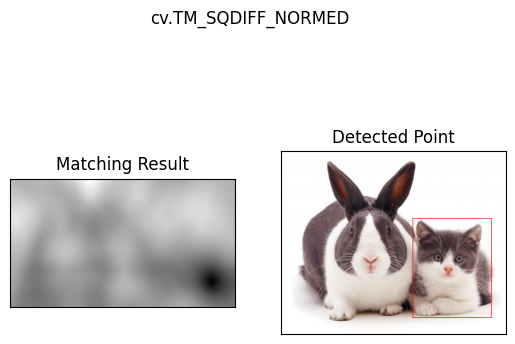

In [5]:
img_color = cv.imread('/content/drive/MyDrive/PCVK/Object Detection/cats_and_bunnies.jpg')
img_gray = cv.cvtColor(img_color, cv.COLOR_BGR2GRAY)
template = cv.imread('/content/drive/MyDrive/PCVK/Object Detection/cat2_templatejpg.jpg', 0)
w, h = template.shape[::-1]

methods = ['cv.TM_CCOEFF', 'cv.TM_CCOEFF_NORMED', 'cv.TM_CCORR',
           'cv.TM_CCORR_NORMED', 'cv.TM_SQDIFF', 'cv.TM_SQDIFF_NORMED']

for meth_name in methods:
    img_color_copy = img_color.copy()
    method = eval(meth_name)

    res = cv.matchTemplate(img_gray, template, method)
    min_val, max_val, min_loc, max_loc = cv.minMaxLoc(res)

    if method in [cv.TM_SQDIFF, cv.TM_SQDIFF_NORMED]:
        top_left = min_loc
    else:
        top_left = max_loc

    bottom_right = (top_left[0] + w, top_left[1] + h)

    cv.rectangle(img_color_copy, top_left, bottom_right, (0, 0, 255), 2)

    img_rgb = cv.cvtColor(img_color_copy, cv.COLOR_BGR2RGB)

    plt.subplot(121), plt.imshow(res, cmap='gray')
    plt.title('Matching Result'), plt.xticks([]), plt.yticks([])
    plt.subplot(122), plt.imshow(img_rgb)
    plt.title('Detected Point'), plt.xticks([]), plt.yticks([])
    plt.suptitle(meth_name)
    plt.show()

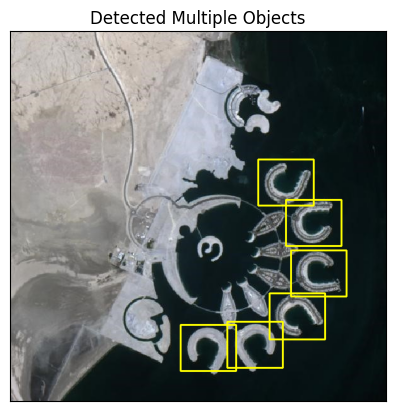

In [11]:
img_rgb = cv.imread('/content/drive/MyDrive/PCVK/Object Detection/bahrain.jpg')
img_gray = cv.cvtColor(img_rgb, cv.COLOR_BGR2GRAY)
template = cv.imread('/content/drive/MyDrive/PCVK/Object Detection/bahrain-template.jpg', 0)
w, h = template.shape[::-1]

res = cv.matchTemplate(img_gray, template, cv.TM_CCOEFF_NORMED)

threshold = 0.45
loc = np.where(res >= threshold)

rectangles = []
for pt in zip(*loc[::-1]):
    rect = [int(pt[0]), int(pt[1]), int(w), int(h)]
    rectangles.append(rect)

boxes, weights = cv.groupRectangles(rectangles, 1, 0.2)

img_bgr_with_boxes = img_rgb.copy()
for (x, y, w, h) in boxes:
    cv.rectangle(img_bgr_with_boxes, (x, y), (x + w, y + h), (0, 255, 255), 2)

img_rgb_with_boxes = cv.cvtColor(img_bgr_with_boxes, cv.COLOR_BGR2RGB)

plt.imshow(img_rgb_with_boxes)
plt.title('Detected Multiple Objects')
plt.xticks([]), plt.yticks([])
plt.show()

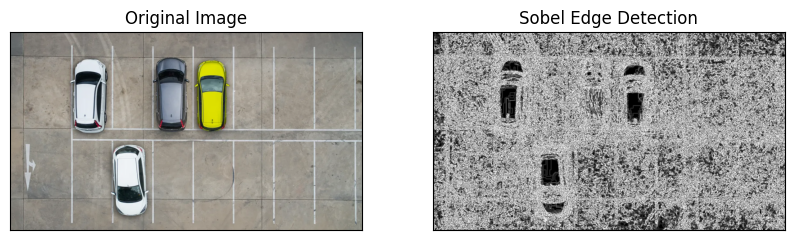

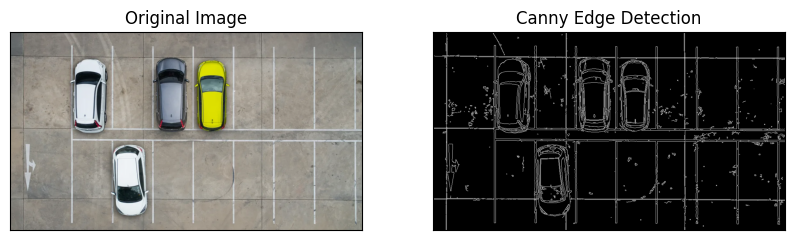

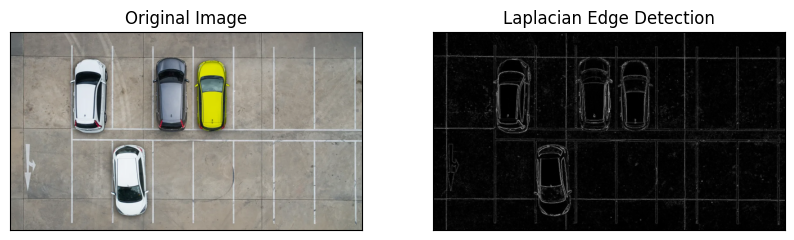

In [12]:
img_color = cv.imread('/content/drive/MyDrive/PCVK/Object Detection/car-park.jpg')
img_rgb = cv.cvtColor(img_color, cv.COLOR_BGR2RGB)
img_gray = cv.cvtColor(img_color, cv.COLOR_BGR2GRAY)

# Sobel Edge Detection

sobelx = cv.Sobel(img_gray, cv.CV_64F, 1, 0, ksize=5)
sobely = cv.Sobel(img_gray, cv.CV_64F, 0, 1, ksize=5)
sobel_combined = cv.bitwise_or(np.uint8(np.absolute(sobelx)),
                             np.uint8(np.absolute(sobely)))

plt.figure(figsize=(10, 5))
plt.subplot(121), plt.imshow(img_rgb)
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(sobel_combined, cmap='gray')
plt.title('Sobel Edge Detection'), plt.xticks([]), plt.yticks([])
plt.show()

# Canny Edge Detection

canny_edges = cv.Canny(img_gray, 50, 150)

plt.figure(figsize=(10, 5))
plt.subplot(121), plt.imshow(img_rgb)
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(canny_edges, cmap='gray')
plt.title('Canny Edge Detection'), plt.xticks([]), plt.yticks([])
plt.show()

# Laplacian Edge Detection

laplacian = cv.Laplacian(img_gray, cv.CV_64F)
laplacian_abs = np.uint8(np.absolute(laplacian))

plt.figure(figsize=(10, 5))
plt.subplot(121), plt.imshow(img_rgb)
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(laplacian_abs, cmap='gray')
plt.title('Laplacian Edge Detection'), plt.xticks([]), plt.yticks([])
plt.show()

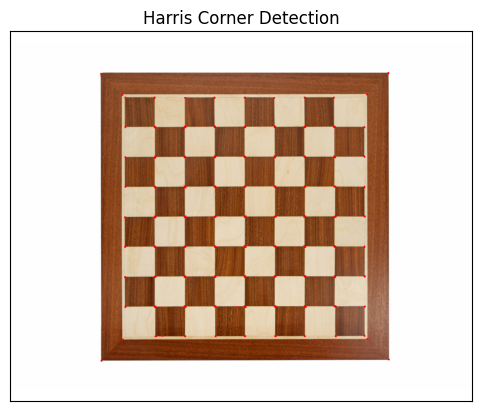

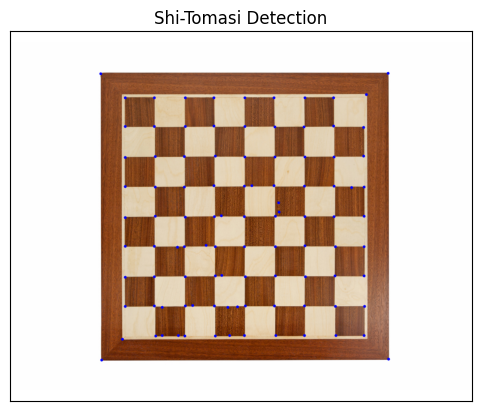

In [17]:
img = cv.imread('/content/drive/MyDrive/PCVK/Object Detection/chess-board.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# a. Harris Corner Detection

img_harris = img_rgb.copy()

gray_float = np.float32(img_gray)
dst = cv.cornerHarris(gray_float, 2, 3, 0.04)

dst = cv.dilate(dst, None)

img_harris[dst > 0.01 * dst.max()] = [255, 0, 0]

plt.imshow(img_harris)
plt.title('Harris Corner Detection')
plt.xticks([]), plt.yticks([])
plt.show()

# Shi-Tomasi Detection

img_shi_tomasi = img_rgb.copy()

corners = cv.goodFeaturesToTrack(img_gray, 100, 0.01, 10)
corners = np.intp(corners)

for i in corners:
    x, y = i.ravel()
    cv.circle(img_shi_tomasi, (x, y), 3, (0, 0, 255), -1)

plt.imshow(img_shi_tomasi)
plt.title('Shi-Tomasi Detection')
plt.xticks([]), plt.yticks([])
plt.show()

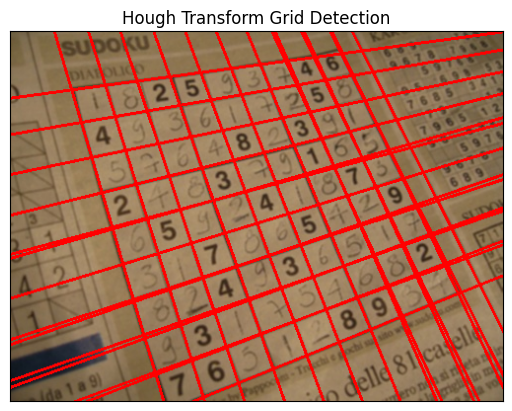

In [47]:
img = cv.imread('/content/drive/MyDrive/PCVK/Object Detection/sudoku.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
img_color_copy = img.copy()

edges = cv.Canny(img_gray, 50, 150, apertureSize=3)

kernel = np.ones((3,3), np.uint8)
img_dilation = cv.dilate(edges, kernel, iterations=1)

img_erosion = cv.erode(img_dilation, kernel, iterations=1)

lines = cv.HoughLines(img_erosion, 1, np.pi / 175, 290)

if lines is not None:
    for line in lines:
        rho, theta = line[0]
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))

        cv.line(img_color_copy, (x1, y1), (x2, y2), (0, 0, 255), 2)

img_rgb = cv.cvtColor(img_color_copy, cv.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title('Hough Transform Grid Detection')
plt.xticks([]), plt.yticks([])
plt.show()

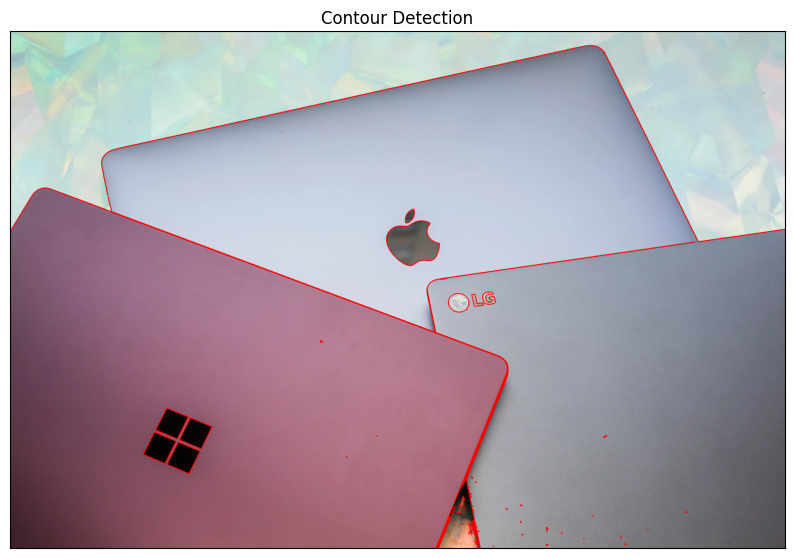

In [48]:
img_color = cv.imread('/content/drive/MyDrive/PCVK/Object Detection/laptop.jpg')
img_gray = cv.cvtColor(img_color, cv.COLOR_BGR2GRAY)

edges = cv.Canny(img_gray, 50, 150)

contours, hierarchy = cv.findContours(edges, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

img_color_copy = img_color.copy()

cv.drawContours(img_color_copy, contours, -1, (0, 0, 255), 3)

img_rgb = cv.cvtColor(img_color_copy, cv.COLOR_BGR2RGB)

plt.figure(figsize=(10, 7))
plt.imshow(img_rgb)
plt.title('Contour Detection')
plt.xticks([]), plt.yticks([])
plt.show()

# D2 Practicum